In [1]:
from fastai.vision.all import *

c:\Users\vmhri\Desktop\Waste_Classifier\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Dataset location
path = Path(r'C:\Users\vmhri\Desktop\Trash_Dataset')

#Extracts images from dataset
files = get_image_files(path)
print(f"Total images (Train + Valid): {len(files)}")

Total images (Train + Valid): 4947


In [ ]:
#FOR SECOND TRAINING RUN

waste_block_448 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='Train', valid_name='Test'),
    get_y=parent_label,
    item_tfms=Resize(512), 
    batch_tfms=[*aug_transforms(size=448, min_scale=0.75), 
                Normalize.from_stats(*imagenet_stats)]
)

dls_448 = waste_block_448.dataloaders(
    path,
    bs=4,               
    num_workers=4, 
    pin_memory=True
)

In [ ]:
#FOR FIRST TRAINING RUN

waste_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='Train', valid_name='Test'),
    get_y=parent_label,
    # 1. PRESIZING: CPU does one quick large crop
    item_tfms=Resize(460), 
    # 2. GPU AUGMENTATION: GPU handles the final 224 resize and flips in parallel
    batch_tfms=[*aug_transforms(size=224, min_scale=0.75), 
                Normalize.from_stats(*imagenet_stats)]
)
dls = waste_block.dataloaders(
    path,
    bs=6,
    num_workers=4,      # Uses multiple CPU cores to prep images
    pin_memory=True,     # Creates a "fast lane" from RAM to GPU
    prefetch_factor=2    # Preps the next batch while the current one is training
)

Total images (Train + Valid): 4947


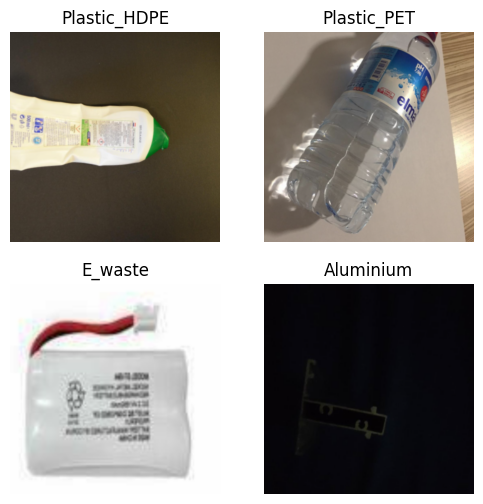

In [ ]:
dls.show_batch()

In [ ]:
#FOR SECOND TRAINING RUN  
  
learn = load_learner('waste_model.pkl')
learn.dls = dls_448
learn.to_fp16()

<div></div>

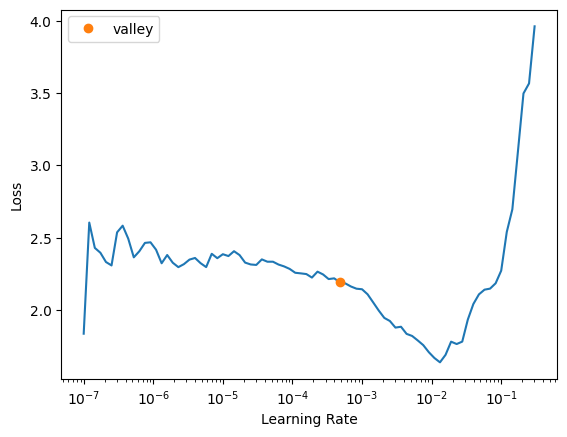

In [ ]:
#FOR FIRST TRAINING RUN

learn = vision_learner(dls, 'convnext_tiny', metrics=error_rate).to_fp16() #fp16() says python to uses 16bit math instead of 32bit math(increase speed)
lrs = learn.lr_find(suggest_funcs=(valley))

In [ ]:
# Use this to prevent the progress bar from ever starting
import fastprogress
fastprogress.fastprogress.printing = lambda: True

from fastai.test_utils import *
#  the fine-tuning
with learn.no_bar():
    learn.fine_tune(3, base_lr=1e-4) #For first training run we use lr provided by valley algorithm

[0, 0.334266722202301, 0.09747683256864548, 0.03379091992974281, '04:45']
[0, 0.3386967182159424, 0.09533075243234634, 0.0295670535415411, '05:48']
[1, 0.3061939477920532, 0.09481019526720047, 0.0295670535415411, '05:57']
[2, 0.2738645672798157, 0.08680311590433121, 0.025343189015984535, '05:58']


In [ ]:
#Sample images to test
alum = 'samples/alum_1_pred.jpg'
e_waste = 'samples/e_waste_3_pred.jpg'
plastic_hdpe = 'samples/plastic_HDPE_1_pred.jpg'
plastic_pet = 'samples/plastic_PET_1_pred.jpg'

pred, pred_idx, probs = learn.predict(plastic_hdpe)

print(f"Prediction: {pred}")
print(f"Confidence: {probs[pred_idx]:.4f}")

Prediction: Plastic_HDPE
Confidence: 0.7745


In [ ]:
learn.export('waste_model_448.pkl')